# Spectral Collocation PDE Solver: Dense Gauss–Newton Methods

**A comparative study of three dense (no-HODLR) optimisation schemes for a
Chebyshev spectral neural-network PDE solver.**

| Method | Description |
|--------|-------------|
| **M0 – Naive** | Direct `np.linalg.lstsq` on the collocation system |
| **M1 – SMW / Woodbury** | Gauss–Newton with the Sherman–Morrison–Woodbury identity |
| **M2 – LSQR** | Matrix-free Gauss–Newton via LSQR on the least-squares system |

---


## 1  Imports and Global Settings

In [24]:
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── reproducibility & precision ────────────────────────────────────────────────
torch.manual_seed(0)
np.random.seed(0)
torch.set_default_dtype(torch.float64)

# ── plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.4,
    "lines.linewidth": 1.8,
    "font.size": 11,
})

print("PyTorch:", torch.__version__)
print("NumPy  :", np.__version__)


PyTorch: 2.10.0
NumPy  : 2.4.3


## 2  Chebyshev Spectral Setup

### 2.1  Chebyshev–Gauss–Lobatto grid

The $N+1$ collocation points on $[-1,1]$ are

$$
x_j = \cos\!\left(\frac{\pi j}{N}\right), \quad j = 0,1,\ldots,N.
$$

### 2.2  Chebyshev differentiation matrix

The $(N+1)\times(N+1)$ matrix $D$ approximates the first derivative:
$u'(x_j) \approx (Du)_j$.  The standard Chebyshev entries are

$$
D_{ij} = \frac{c_i}{c_j}\frac{(-1)^{i+j}}{x_i - x_j}, \quad i\neq j,
\qquad
D_{ii} = -\sum_{j\neq i} D_{ij},
$$

where $c_0 = c_N = 2$, all other $c_k = 1$.

### 2.3  Overdetermined collocation operator

For the BVP $-u'' = f$ with $u(\pm 1)=0$ we build an overdetermined system
$Au = \tilde f$ by stacking the PDE rows $(-D^2)$ with two boundary rows:

$$
A = \begin{bmatrix} -D^2 \\ \lambda e_0^T \\ \lambda e_N^T \end{bmatrix}, \quad
\tilde f = \begin{bmatrix} f(x) \\ 0 \\ 0 \end{bmatrix}.
$$

$\lambda$ is a penalty weight that enforces the boundary conditions strongly.


In [25]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.1 / 2.2  Chebyshev grid and differentiation matrix
# ──────────────────────────────────────────────────────────────────────────────

def chebyshev_cgl(N: int) -> torch.Tensor:
    """Return N+1 Chebyshev–Gauss–Lobatto points on [-1, 1]."""
    j = torch.arange(N + 1, dtype=torch.float64)
    return torch.cos(torch.pi * j / N)


def chebyshev_diff_matrix(N: int):
    """Return (x, D) where D is the (N+1)×(N+1) differentiation matrix."""
    x = chebyshev_cgl(N)

    c = torch.ones(N + 1, dtype=torch.float64)
    c[0] = c[-1] = 2.0

    X  = x.unsqueeze(0)
    dX = X.T - X + torch.eye(N + 1)          # diagonal offset to avoid /0

    sign    = (-1.0) ** (torch.arange(N + 1).unsqueeze(0) +
                          torch.arange(N + 1).unsqueeze(1))
    C_ratio = c.unsqueeze(0).T / c.unsqueeze(0)

    D = C_ratio * sign / dX
    D = D - torch.diag(D.sum(dim=1))         # fix diagonal

    return x, D


# ──────────────────────────────────────────────────────────────────────────────
# 2.3  Collocation operator A and RHS
# ──────────────────────────────────────────────────────────────────────────────

def build_operator(D: torch.Tensor, bc_weight: float = 10.0):
    """Return A = [-D², bc rows], shape (N+3, N+1)."""
    N   = D.shape[0] - 1
    D2  = D @ D
    A_pde = -D2

    bc        = torch.zeros(2, N + 1, dtype=torch.float64)
    bc[0,  0] = bc_weight
    bc[1, -1] = bc_weight

    return torch.cat([A_pde, bc], dim=0)


def build_rhs(x: torch.Tensor) -> torch.Tensor:
    """RHS for -u'' = π² sin(πx), extended with two zero BC entries."""
    f = (torch.pi ** 2) * torch.sin(torch.pi * x)
    return torch.cat([f, torch.zeros(2)])


def true_solution(x: torch.Tensor) -> torch.Tensor:
    """Exact solution u(x) = sin(πx)."""
    return torch.sin(torch.pi * x)


## 3  Chebyshev Polynomial Basis

The solution is parameterised as

$$
u(x) \approx \sum_{k=0}^{K-1} c_k \, T_k(x) = \Phi c,
$$

where $T_k(x) = \cos(k \arccos x)$ are Chebyshev polynomials and
$\Phi_{ik} = T_k(x_i)$ is the $(N+1)\times K$ basis matrix.


In [26]:
def chebyshev_basis(x: torch.Tensor, K: int) -> torch.Tensor:
    """Return (N+1)×K basis matrix Φ[i,k] = T_k(x_i)."""
    theta = torch.arccos(x.clamp(-1 + 1e-12, 1 - 1e-12))
    k     = torch.arange(K, dtype=torch.float64)
    return torch.cos(theta.unsqueeze(1) * k.unsqueeze(0))


## 4  Neural-Network Coefficient Model

Rather than optimising $c$ directly we embed it as the output of a small MLP
$c = \mathcal{N}_\theta(\cdot)$.  This allows us to use automatic
differentiation to build the Jacobian $B = \partial c/\partial\theta$
and apply second-order Gauss–Newton updates in parameter space $\theta$.

The network architecture is:

$$
\mathcal{N}_\theta: \mathbb{R}^1 \to \mathbb{R}^K, \quad
1 \xrightarrow{\text{Linear}} 64 \xrightarrow{\tanh}
64 \xrightarrow{\tanh} 64 \xrightarrow{\tanh} K.
$$


In [27]:
class CoeffNet(nn.Module):
    """Small MLP that outputs K Chebyshev coefficients."""

    def __init__(self, K: int, hidden: int = 8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, K),
        )
        # Xavier initialisation for stability
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self) -> torch.Tensor:
        return self.net(torch.ones(1, 1, dtype=torch.float64)).view(-1)


def num_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


def build_jacobian_B(model: CoeffNet) -> torch.Tensor:
    """Return B = ∂c/∂θ, shape (K, P), via autograd."""
    c = model()
    K = c.shape[0]
    P = num_params(model)
    B = torch.zeros(K, P, dtype=torch.float64)

    for k in range(K):
        model.zero_grad()
        c[k].backward(retain_graph=True)
        grads = [p.grad.detach().view(-1) for p in model.parameters()]
        B[k] = torch.cat(grads)
    return B


def compute_residual(model: CoeffNet,
                     A: torch.Tensor,
                     Phi: torch.Tensor,
                     f: torch.Tensor):
    """Return (r, u, c)  where  r = A Φ c − f."""
    c = model()
    u = Phi @ c
    r = A @ u - f
    return r, u, c


def apply_update(model: CoeffNet,
                 delta: torch.Tensor,
                 lr: float = 0.1) -> None:
    """In-place parameter update: θ ← θ + lr·Δθ."""
    idx = 0
    for p in model.parameters():
        n = p.numel()
        p.data += lr * delta[idx:idx + n].view_as(p)
        idx += n

## 5  Problem Setup Helper

In [28]:
def choose_K(N: int, K_min: int = 10, K_max: int = 256) -> int:
    """
    Choose the number of Chebyshev basis functions.
    Rule: K = max(K_min, min(K_max, N//2 + 1))
    Larger K → richer approximation space.
    """
    return max(K_min, min(K_max, N // 3 + 1))
    # return 20


def setup_problem(N: int, bc_weight: float = 10.0):
    """
    Build all shared objects for a given N.

    Returns
    -------
    x    : (N+1,) collocation points
    A    : (N+3, N+1) collocation operator
    Phi  : (N+1, K) Chebyshev basis
    f    : (N+3,) extended RHS
    K    : number of basis functions
    """
    x, D = chebyshev_diff_matrix(N)
    A    = build_operator(D, bc_weight=bc_weight)
    K    = choose_K(N)
    Phi  = chebyshev_basis(x, K)
    f    = build_rhs(x)
    return x, A, Phi, f, K


## 6  Method 0 – Naive Baseline

We directly solve the overdetermined collocation system

$$
\min_u \|Au - \tilde f\|_2
$$

using `numpy.linalg.lstsq` (LAPACK DGELSD).  This is the gold-standard
reference: optimal accuracy at $O(N^3)$ cost.


In [29]:
def run_method_0(N: int, bc_weight: float = 10.0) -> dict:
    """Naive least-squares baseline."""
    t0 = time.perf_counter()
    x, A, _, f, _ = setup_problem(N, bc_weight=bc_weight)
    A_np = A.numpy()
    f_np = f.numpy()
    t1 = time.perf_counter()

    u_np, *_ = np.linalg.lstsq(A_np, f_np, rcond=None)
    t2 = time.perf_counter()

    u_pred = torch.from_numpy(u_np)
    u_true = true_solution(x)
    l2_err = (torch.norm(u_pred - u_true) / torch.norm(u_true)).item()

    return {
        "N": N, "method": "Naive",
        "init_time":  t1 - t0,
        "train_time": t2 - t1,
        "total_time": t2 - t0,
        "l2_error":   l2_err,
        "x": x.numpy(), "u_pred": u_np, "u_true": u_true.numpy(),
    }


## 7  Method 1 – Gauss–Newton with Woodbury / SMW Identity

### 7.1  Gauss–Newton normal equations

The full Jacobian is $J = A\Phi B \in \mathbb{R}^{(N+3)\times P}$.
The Levenberg–Marquardt (damped Gauss–Newton) update solves

$$
(J^\top J + \mu I)\,\Delta\theta = -J^\top r.
$$

### 7.2  Sherman–Morrison–Woodbury formula

We exploit the factored structure $J = A\Phi B$ to avoid forming $J$ explicitly.
Define $G = (A\Phi)^\top (A\Phi) \in \mathbb{R}^{K\times K}$. Then

$$
J^\top J = B^\top G B,
$$

and the SMW identity gives

$$
\bigl(\mu I + B^\top G B\bigr)^{-1}
= \frac{1}{\mu}\Bigl[I - B^\top\bigl(\mu G^{-1} + BB^\top\bigr)^{-1}B\Bigr].
$$

Because $K \ll P$ (few basis functions vs.\ many network parameters) the
$K\times K$ system is cheap to invert, while the $P\times P$ system is never
formed.

The parameter update is therefore

$$
\Delta\theta = -\frac{1}{\mu}\Bigl[I - B^\top M^{-1} B\Bigr]\,g,
\qquad
M = \mu G^{-1} + BB^\top,\quad
g = B^\top \Phi^\top A^\top r.
$$

$A$ and $\Phi$ are fixed, so $G$ is computed **once** before the loop.


In [30]:
# ── Dense helpers for Method 1 & 2 ────────────────────────────────────────────

def compute_G(A: torch.Tensor, Phi: torch.Tensor) -> tuple:
    """
    Return (APhi, G) where G = (AΦ)ᵀ(AΦ).
    Cached once per problem (A and Phi are fixed).
    """
    APhi = A @ Phi          # (N+3, K)
    G    = APhi.T @ APhi    # (K, K)
    return APhi, G


def compute_mu(G: torch.Tensor, lam: float) -> torch.Tensor:
    """
    Tiny ridge term used only to keep the inverse well-defined.
    lam is kept for API compatibility but is not used to scale the damping.
    """
    return torch.as_tensor(lam, dtype=G.dtype, device=G.device)


def compute_gradient_g(A: torch.Tensor,
                       Phi: torch.Tensor,
                       B: torch.Tensor,
                       r: torch.Tensor) -> torch.Tensor:
    """g = Bᵀ Φᵀ Aᵀ r  (parameter-space gradient), shape (P,)."""
    return B.T @ (Phi.T @ (A.T @ r))


# ── SMW solve ─────────────────────────────────────────────────────────────────

def solve_smw(G: torch.Tensor,
              B: torch.Tensor,
              g: torch.Tensor,
              mu: torch.Tensor,
              reg: float = 1e-8) -> torch.Tensor:
    """
    Δθ = −(1/μ)[I − Bᵀ M⁻¹ B] g
    M  = μ G⁻¹ + BBᵀ       (K×K, cheap to invert)
    """
    G_reg   = G + reg * torch.eye(G.shape[0], dtype=G.dtype)
    G_inv   = torch.linalg.inv(G_reg)
    BBt     = B @ B.T
    M       = mu * G_inv + BBt
    M_inv   = torch.linalg.inv(M)

    Bg      = B @ g
    middle  = B.T @ (M_inv @ Bg)
    return -(1.0 / mu) * (g - middle)


# ── Training loop ─────────────────────────────────────────────────────────────

def train_smw_dense(model: CoeffNet,
                    A: torch.Tensor,
                    Phi: torch.Tensor,
                    f: torch.Tensor,
                    steps: int = 500,
                    lam: float = 1e-3,
                    lr: float   = 0.1) -> list:
    """
    Gauss–Newton / Woodbury (SMW) training loop.
    G is cached once; only B and r change per iteration.
    """
    APhi, G = compute_G(A, Phi)
    mu      = compute_mu(G, lam)
    losses  = []

    for _ in range(steps):
        B       = build_jacobian_B(model)
        r, _, _ = compute_residual(model, A, Phi, f)
        losses.append(torch.norm(r).item())

        g            = compute_gradient_g(A, Phi, B, r)
        delta_theta  = solve_smw(G, B, g, mu)
        apply_update(model, delta_theta, lr=lr)

    return losses


def run_method_1(N: int,
                 steps: int   = 500,
                 lam: float   = 1e-3,
                 lr: float    = 0.1,
                 bc_weight: float = 10.0) -> dict:
    """End-to-end runner for Method 1."""
    t0 = time.perf_counter()
    x, A, Phi, f, K = setup_problem(N, bc_weight=bc_weight)
    model = CoeffNet(K)
    t1 = time.perf_counter()

    losses = train_smw_dense(model, A, Phi, f, steps=steps, lam=lam, lr=lr)
    t2 = time.perf_counter()

    with torch.no_grad():
        c      = model()
        u_pred = Phi @ c
        u_true = true_solution(x)

    l2_err = (torch.norm(u_pred - u_true) / torch.norm(u_true)).item()

    return {
        "N": N, "method": "SMW",
        "init_time":  t1 - t0,
        "train_time": t2 - t1,
        "total_time": t2 - t0,
        "l2_error":   l2_err,
        "losses":     losses,
        "x": x.numpy(), "u_pred": u_pred.numpy(), "u_true": u_true.numpy(),
    }

## 8  Method 2 – Matrix-Free Gauss–Newton via LSQR

### 8.1  Augmented least-squares formulation

The damped Gauss–Newton system $(J^\top J+\mu I)\Delta\theta=-J^\top r$
is equivalent to the least-squares problem

$$
\min_{\Delta\theta}
\left\|
\begin{bmatrix} J \\ \sqrt{\mu}\,I \end{bmatrix}
\Delta\theta
-
\begin{bmatrix} -r \\ 0 \end{bmatrix}
\right\|_2.
$$

Define $Q = \bigl[J;\;\sqrt{\mu}\,I\bigr]$.

### 8.2  Matrix-free operator actions

We never form $J = A\Phi B$ explicitly.  Instead we implement two cheap
operator applications using the factored structure $J = A\Phi B$:

**Forward action** $y = Qx$:

$$
Qx = \begin{bmatrix} A\,\Phi\,(Bx) \\ \sqrt{\mu}\,x \end{bmatrix}
$$

**Adjoint action** $z = Q^\top y$, splitting $y=(y_1, y_2)$:

$$
Q^\top y = B^\top\!\left(\Phi^\top\!\left(A^\top y_1\right)\right) + \sqrt{\mu}\,y_2
$$

### 8.3  LSQR algorithm

LSQR (Paige & Saunders 1982) is a Krylov method for least-squares systems
that only requires $Qx$ and $Q^\top y$.  It produces iterates equivalent to
the conjugate-gradient method applied to the normal equations, with superior
numerical stability.


In [31]:
# ── Matrix-free Q operator (dense A) ─────────────────────────────────────────

def forward_Q(A: torch.Tensor,
              Phi: torch.Tensor,
              B: torch.Tensor,
              x: torch.Tensor,
              mu: torch.Tensor) -> torch.Tensor:
    """y = Q x  where Q = [J; sqrt(μ)I], J = AΦB."""
    return torch.cat([A @ (Phi @ (B @ x)),
                      mu.sqrt() * x])


def adjoint_Q(A: torch.Tensor,
              Phi: torch.Tensor,
              B: torch.Tensor,
              y: torch.Tensor,
              mu: torch.Tensor) -> torch.Tensor:
    """z = Qᵀ y."""
    Np3 = A.shape[0]
    y1, y2 = y[:Np3], y[Np3:]
    return B.T @ (Phi.T @ (A.T @ y1)) + mu.sqrt() * y2


# ── LSQR solver ───────────────────────────────────────────────────────────────

def lsqr_solver(A: torch.Tensor,
                Phi: torch.Tensor,
                B: torch.Tensor,
                r: torch.Tensor,
                mu: torch.Tensor,
                max_iter: int = 50) -> torch.Tensor:
    """
    Solve  min ||Q Δθ − b||  via LSQR.
    b = [−r ; 0].
    Returns Δθ of shape (P,).
    """
    P = B.shape[1]
    b = torch.cat([-r, torch.zeros(P, dtype=r.dtype)])
    x = torch.zeros(P, dtype=r.dtype)

    # ── Initialisation ──────────────────────────────────────────────────────
    u    = b.clone()
    beta = torch.norm(u)
    if beta < 1e-14:
        return x
    u /= beta

    v     = adjoint_Q(A, Phi, B, u, mu)
    alpha = torch.norm(v)
    if alpha < 1e-14:
        return x
    v /= alpha

    w       = v.clone()
    phi_bar = beta
    rho_bar = alpha

    # ── Bidiagonalisation + QR ──────────────────────────────────────────────
    for _ in range(max_iter):
        u     = forward_Q(A, Phi, B, v, mu) - alpha * u
        beta  = torch.norm(u)
        if beta < 1e-14:
            break
        u /= beta

        v     = adjoint_Q(A, Phi, B, u, mu) - beta * v
        alpha = torch.norm(v)
        if alpha < 1e-14:
            break
        v /= alpha

        rho   = torch.sqrt(rho_bar ** 2 + beta ** 2)
        c     = rho_bar / rho
        s     = beta   / rho
        theta = s * alpha
        rho_bar = -c * alpha
        phi     = c * phi_bar
        phi_bar = s * phi_bar

        x = x + (phi / rho) * w
        w = v - (theta / rho) * w

    return x


# ── Training loop ─────────────────────────────────────────────────────────────

def train_lsqr_dense(model: CoeffNet,
                     A: torch.Tensor,
                     Phi: torch.Tensor,
                     f: torch.Tensor,
                     steps: int     = 500,
                     lam: float     = 1e-3,
                     lsqr_iters: int = 50,
                     lr: float       = 0.1) -> list:
    """
    LSQR-based Gauss–Newton training loop.
    G is cached once; LSQR is run from scratch each step.
    """
    _, G = compute_G(A, Phi)
    mu   = compute_mu(G, lam)
    losses = []

    for _ in range(steps):
        B       = build_jacobian_B(model)
        r, _, _ = compute_residual(model, A, Phi, f)
        losses.append(torch.norm(r).item())

        delta_theta = lsqr_solver(A, Phi, B, r, mu, max_iter=lsqr_iters)
        apply_update(model, delta_theta, lr=lr)

    return losses


def run_method_2(N: int,
                 steps: int      = 500,
                 lam: float      = 1e-3,
                 lsqr_iters: int = 50,
                 lr: float       = 0.1,
                 bc_weight: float = 10.0) -> dict:
    """End-to-end runner for Method 2."""
    t0 = time.perf_counter()
    x, A, Phi, f, K = setup_problem(N, bc_weight=bc_weight)
    model = CoeffNet(K)
    t1 = time.perf_counter()

    losses = train_lsqr_dense(model, A, Phi, f,
                               steps=steps, lam=lam,
                               lsqr_iters=lsqr_iters, lr=lr)
    t2 = time.perf_counter()

    with torch.no_grad():
        c      = model()
        u_pred = Phi @ c
        u_true = true_solution(x)

    l2_err = (torch.norm(u_pred - u_true) / torch.norm(u_true)).item()

    return {
        "N": N, "method": "LSQR",
        "init_time":  t1 - t0,
        "train_time": t2 - t1,
        "total_time": t2 - t0,
        "l2_error":   l2_err,
        "losses":     losses,
        "x": x.numpy(), "u_pred": u_pred.numpy(), "u_true": u_true.numpy(),
    }

## 9  Adjoint Consistency Check

Verify $\langle Qx, y\rangle = \langle x, Q^\top y\rangle$ to machine precision.

In [32]:
def check_adjoint(N: int = 20, tol: float = 1e-9) -> None:
    x_p, A, Phi, f, K = setup_problem(N)
    model  = CoeffNet(K)
    B      = build_jacobian_B(model)
    _, G   = compute_G(A, Phi)
    mu     = compute_mu(G, 1e-3)
    P      = B.shape[1]

    xv = torch.randn(P, dtype=torch.float64)
    yv = torch.randn(A.shape[0] + P, dtype=torch.float64)

    lhs = torch.dot(forward_Q(A, Phi, B, xv, mu), yv)
    rhs = torch.dot(xv, adjoint_Q(A, Phi, B, yv, mu))
    err = abs(lhs.item() - rhs.item())

    print(f"Adjoint error = {err:.3e}  ({'PASS ✓' if err < tol else 'FAIL ✗'})")

check_adjoint()

Adjoint error = 3.638e-12  (PASS ✓)


## 10  Benchmark: Full N-Sweep

All three methods are run across a range of grid sizes.
For Methods 1 and 2 the model is shared per N so only one `setup_problem`
call is made.

Hyper-parameters:

| Symbol | Value |
|--------|-------|
| Steps  | 500 |
| $\lambda$ (damping) | $10^{-3}$ |
| LSQR inner iterations | 50 |
| Learning rate $\alpha$ | 0.1 |
| BC penalty $\lambda_{bc}$ | 10 |


In [33]:
# ── Configuration ─────────────────────────────────────────────────────────────
N_SMALL = [4, 12, 20, 28, 36, 44, 52, 60]
N_LARGE = [100, 200, 300, 400, 500, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
N_ALL   = N_SMALL + N_LARGE

STEPS      = 300
LAM        = 1e-3
LSQR_ITERS = 5
LR         = 0.1
BC_WEIGHT  = 10.0

# ── Run ───────────────────────────────────────────────────────────────────────

naive_res   = []
smw_res     = []
lsqr_res    = []

for N in N_ALL:
    print(f"N = {N:4d}", end=" ", flush=True)

    # Naive (only finite for small N — still runs for all N via lstsq)
    naive_res.append(run_method_0(N, bc_weight=BC_WEIGHT))
    print("M0✓", end=" ", flush=True)

    # Shared setup for M1 and M2
    x, A, Phi, f, K = setup_problem(N, bc_weight=BC_WEIGHT)
    t_init_start = time.perf_counter()
    t_init_end   = time.perf_counter()
    shared_init  = t_init_end - t_init_start

    # Method 1
    t0 = time.perf_counter()
    model_smw = CoeffNet(K)
    losses_smw = train_smw_dense(model_smw, A, Phi, f,
                                  steps=STEPS, lam=LAM, lr=LR)
    t1 = time.perf_counter()
    with torch.no_grad():
        u_pred_smw = Phi @ model_smw()
        u_true     = true_solution(x)
    smw_res.append({
        "N": N, "method": "SMW",
        "init_time":  0.0,
        "train_time": t1 - t0,
        "total_time": t1 - t0,
        "l2_error":   (torch.norm(u_pred_smw - u_true) / torch.norm(u_true)).item(),
        "losses":     losses_smw,
        "x": x.numpy(), "u_pred": u_pred_smw.numpy(), "u_true": u_true.numpy(),
    })
    print("M1✓", end=" ", flush=True)

    # Method 2
    t2 = time.perf_counter()
    model_lsqr = CoeffNet(K)
    losses_lsqr = train_lsqr_dense(model_lsqr, A, Phi, f,
                                    steps=STEPS, lam=LAM,
                                    lsqr_iters=LSQR_ITERS, lr=LR)
    t3 = time.perf_counter()
    with torch.no_grad():
        u_pred_lsqr = Phi @ model_lsqr()
    lsqr_res.append({
        "N": N, "method": "LSQR",
        "init_time":  0.0,
        "train_time": t3 - t2,
        "total_time": t3 - t2,
        "l2_error":   (torch.norm(u_pred_lsqr - u_true) / torch.norm(u_true)).item(),
        "losses":     losses_lsqr,
        "x": x.numpy(), "u_pred": u_pred_lsqr.numpy(), "u_true": u_true.numpy(),
    })
    print("M2✓")

print("\nDone.")

N =    4 M0✓ M1✓ M2✓
N =   12 M0✓ M1✓ M2✓
N =   20 M0✓ M1✓ M2✓
N =   28 M0✓ M1✓ M2✓
N =   36 M0✓ M1✓ M2✓
N =   44 M0✓ M1✓ M2✓
N =   52 M0✓ M1✓ M2✓
N =   60 M0✓ M1✓ M2✓
N =  100 M0✓ M1✓ M2✓
N =  200 M0✓ M1✓ M2✓
N =  300 M0✓ M1✓ M2✓
N =  400 M0✓ M1✓ M2✓
N =  500 M0✓ M1✓ M2✓
N = 1000 M0✓ M1✓ M2✓
N = 2000 M0✓ M1✓ M2✓
N = 3000 M0✓ M1✓ M2✓
N = 4000 M0✓ M1✓ M2✓
N = 5000 M0✓ M1✓ M2✓
N = 6000 M0✓ M1✓ M2✓
N = 7000 M0✓ M1✓ M2✓
N = 8000 M0✓ M1✓ M2✓
N = 9000 M0✓ M1✓ M2✓
N = 10000 M0✓ M1✓ M2✓

Done.


## 11  Plotting Utilities

In [34]:
COLORS = {"Naive": "#2c7bb6", "SMW": "#d7191c", "LSQR": "#1a9641"}
MARKS  = {"Naive": "^", "SMW": "o", "LSQR": "s"}
LABELS = {"Naive": "Naive (lstsq)", "SMW": "SMW / Woodbury", "LSQR": "LSQR"}


def _series(results, key, N_list):
    lookup = {r["N"]: r[key] for r in results}
    return [lookup.get(n, np.nan) for n in N_list]


def _ax_setup(ax, title, xlabel, ylabel, logy=False):
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if logy:
        ax.set_yscale("log")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)


def plot_metric(N_list, results_dict, key, title, ylabel,
                logy=False, figsize=(7, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    for name, results in results_dict.items():
        y = _series(results, key, N_list)
        ax.plot(N_list, y,
                marker=MARKS[name], color=COLORS[name],
                label=LABELS[name], linewidth=1.8)
    _ax_setup(ax, title, "N (collocation points)", ylabel, logy=logy)
    plt.tight_layout()
    plt.show()


def plot_solutions(result_m0, result_m1, result_m2, N: int):
    x      = result_m0["x"]
    u_true = result_m0["u_true"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: solution overlay
    ax = axes[0]
    ax.plot(x, u_true,            color="k",            lw=2,   label="True $u(x)$")
    ax.plot(x, result_m0["u_pred"], "--",  color=COLORS["Naive"], label=LABELS["Naive"])
    ax.plot(x, result_m1["u_pred"], "-.",  color=COLORS["SMW"],   label=LABELS["SMW"])
    ax.plot(x, result_m2["u_pred"], ":",   color=COLORS["LSQR"],  label=LABELS["LSQR"])
    ax.set_title(f"Solution Comparison  (N={N})", fontweight="bold")
    ax.set_xlabel("x");  ax.set_ylabel("u(x)")
    ax.legend(fontsize=9);  ax.grid(alpha=0.4)

    # Right: absolute error
    ax = axes[1]
    ax.semilogy(x, np.abs(result_m0["u_pred"] - u_true), "--",
                color=COLORS["Naive"], label=LABELS["Naive"])
    ax.semilogy(x, np.abs(result_m1["u_pred"] - u_true), "-.",
                color=COLORS["SMW"],   label=LABELS["SMW"])
    ax.semilogy(x, np.abs(result_m2["u_pred"] - u_true), ":",
                color=COLORS["LSQR"],  label=LABELS["LSQR"])
    ax.set_title(f"Pointwise Error  (N={N})", fontweight="bold")
    ax.set_xlabel("x");  ax.set_ylabel("|error|")
    ax.legend(fontsize=9);  ax.grid(alpha=0.4)

    plt.tight_layout()
    plt.show()


def plot_convergence(results_list, title="Convergence", N_label=None):
    fig, ax = plt.subplots(figsize=(7, 4))
    for r in results_list:
        name = r["method"]
        ax.semilogy(r["losses"], color=COLORS[name],
                    label=f"{LABELS[name]}" + (f"  (N={r['N']})" if N_label else ""))
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Iteration");  ax.set_ylabel("Residual norm")
    ax.legend(fontsize=9);  ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()


def plot_error_vs_N_split(N_small, N_large,
                          naive_res, smw_res, lsqr_res):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, Nlist, tag in zip(axes,
                               [N_small, N_large],
                               ["Small N", "Large N"]):
        for name, res in [("Naive", naive_res),
                           ("SMW",   smw_res),
                           ("LSQR",  lsqr_res)]:
            y = _series(res, "l2_error", Nlist)
            ax.semilogy(Nlist, y, marker=MARKS[name],
                        color=COLORS[name], label=LABELS[name])
        ax.set_title(f"Relative L2 Error ({tag})", fontweight="bold")
        ax.set_xlabel("N");  ax.set_ylabel("Relative L2 Error")
        ax.legend(fontsize=9);  ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()


def plot_time_breakdown(N_list, naive_res, smw_res, lsqr_res):
    """Grouped-bar chart of training time."""
    idx = np.arange(len(N_list))
    w   = 0.25

    naive_t = _series(naive_res, "train_time", N_list)
    smw_t   = _series(smw_res,   "train_time", N_list)
    lsqr_t  = _series(lsqr_res,  "train_time", N_list)

    fig, ax = plt.subplots(figsize=(max(8, len(N_list) * 0.9), 4))
    ax.bar(idx - w, naive_t, w, label=LABELS["Naive"], color=COLORS["Naive"], alpha=0.8)
    ax.bar(idx,     smw_t,   w, label=LABELS["SMW"],   color=COLORS["SMW"],   alpha=0.8)
    ax.bar(idx + w, lsqr_t,  w, label=LABELS["LSQR"],  color=COLORS["LSQR"],  alpha=0.8)
    ax.set_xticks(idx);  ax.set_xticklabels([str(n) for n in N_list], rotation=45)
    ax.set_xlabel("N");  ax.set_ylabel("Training Time (s)")
    ax.set_title("Training Time Breakdown per N", fontweight="bold")
    ax.legend(fontsize=9);  ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    plt.show()


## 12  Results and Plots

### 12.1  Solution and Pointwise Error (representative N)

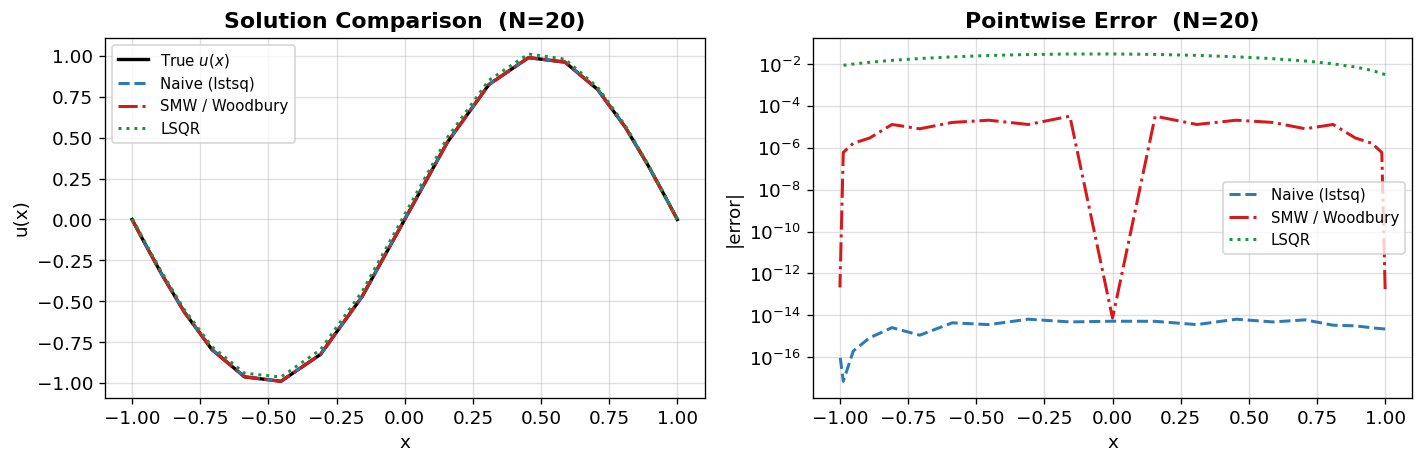

In [35]:
# Pick a representative N to illustrate the solution quality
REP_N = 20
m0 = next(r for r in naive_res if r["N"] == REP_N)
m1 = next(r for r in smw_res   if r["N"] == REP_N)
m2 = next(r for r in lsqr_res  if r["N"] == REP_N)

plot_solutions(m0, m1, m2, N=REP_N)


### 12.2  Convergence Curves

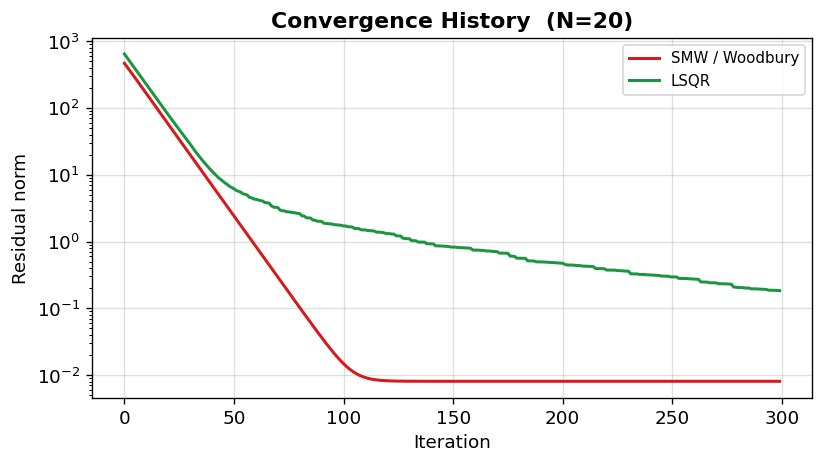

In [36]:
# Convergence for the representative N
plot_convergence([m1, m2],
                 title=f"Convergence History  (N={REP_N})")


### 12.3  Relative L2 Error vs N (small and large)

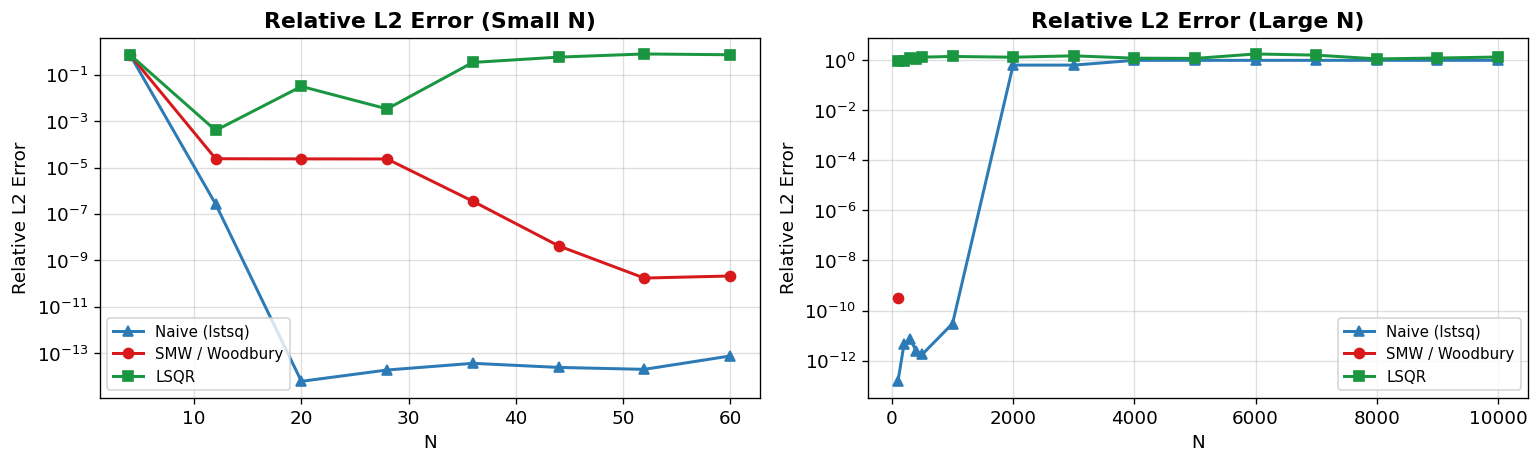

In [37]:
plot_error_vs_N_split(N_SMALL, N_LARGE,
                      naive_res, smw_res, lsqr_res)


### 12.4  Training Time vs N

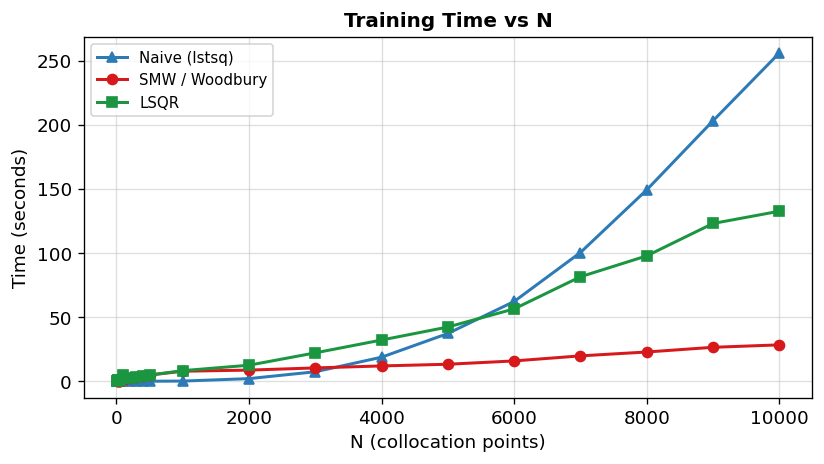

In [38]:
plot_metric(N_ALL, {"Naive": naive_res, "SMW": smw_res, "LSQR": lsqr_res},
            key="train_time",
            title="Training Time vs N",
            ylabel="Time (seconds)")


### 12.5  Training Time – small N only (bar chart)

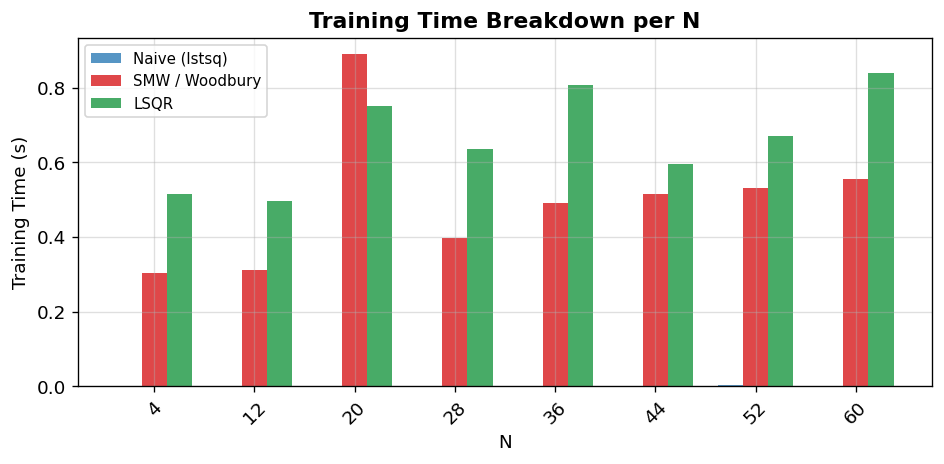

In [39]:
plot_time_breakdown(N_SMALL, naive_res, smw_res, lsqr_res)


### 12.6  Total Time vs N (log scale)

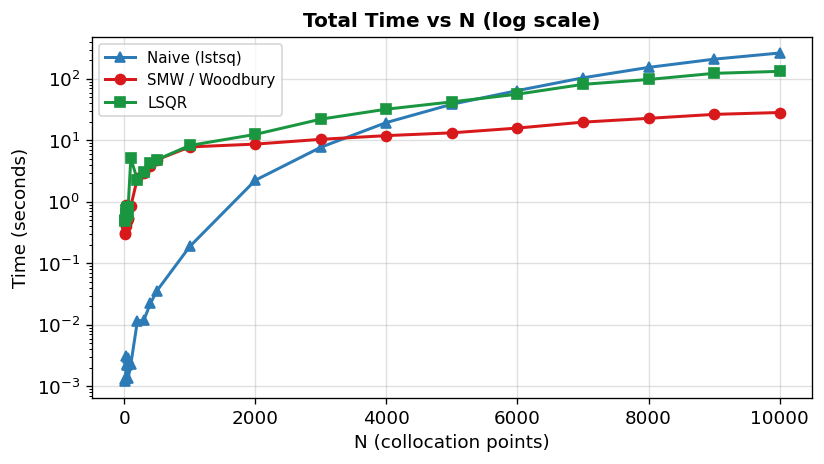

In [40]:
plot_metric(N_ALL, {"Naive": naive_res, "SMW": smw_res, "LSQR": lsqr_res},
            key="total_time",
            title="Total Time vs N (log scale)",
            ylabel="Time (seconds)",
            logy=True)


### 12.7  Error vs N (all methods, log scale)

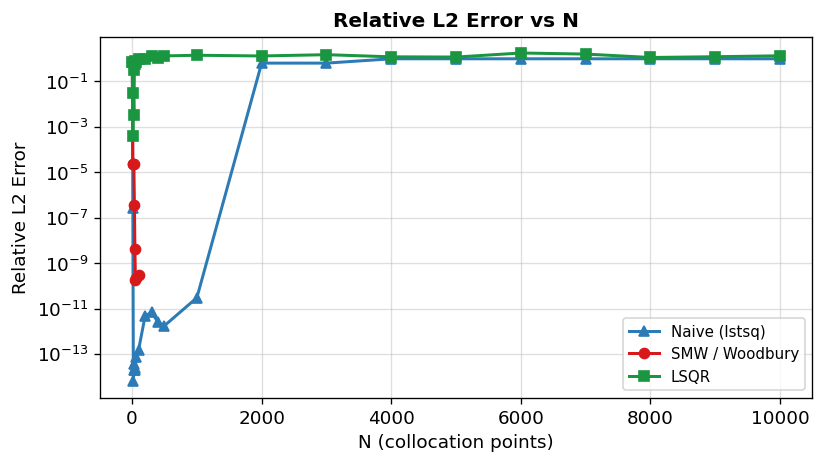

In [41]:
plot_metric(N_ALL, {"Naive": naive_res, "SMW": smw_res, "LSQR": lsqr_res},
            key="l2_error",
            title="Relative L2 Error vs N",
            ylabel="Relative L2 Error",
            logy=True)


### 12.8  Convergence curves across multiple N values

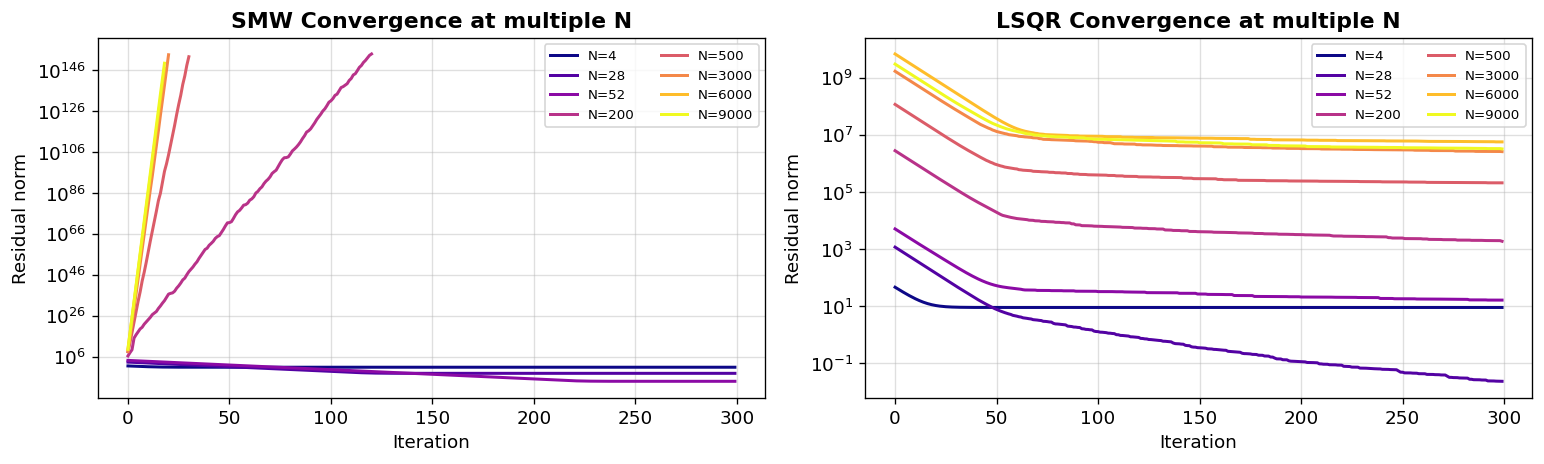

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, method_name, res_list, title in [
    (axes[0], "SMW",  smw_res,  "SMW Convergence at multiple N"),
    (axes[1], "LSQR", lsqr_res, "LSQR Convergence at multiple N"),
]:
    cmap = plt.cm.plasma
    sampled_N = N_ALL[::max(1, len(N_ALL)//6)]
    for i, N in enumerate(sampled_N):
        r = next((x for x in res_list if x["N"] == N), None)
        if r is None:
            continue
        color = cmap(i / max(len(sampled_N) - 1, 1))
        ax.semilogy(r["losses"], color=color, label=f"N={N}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Iteration");  ax.set_ylabel("Residual norm")
    ax.legend(fontsize=8, ncol=2);  ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()


## 13  Numerical Summary Table

In [43]:
print(f"{'N':>5}  {'Naive err':>12}  {'SMW err':>12}  {'LSQR err':>12}  "      f"{'Naive t':>9}  {'SMW t':>9}  {'LSQR t':>9}")
print("-" * 82)

for N in N_ALL:
    m0 = next((r for r in naive_res if r["N"] == N), None)
    m1 = next((r for r in smw_res   if r["N"] == N), None)
    m2 = next((r for r in lsqr_res  if r["N"] == N), None)

    e0 = f"{m0['l2_error']:.3e}" if m0 else "—"
    e1 = f"{m1['l2_error']:.3e}" if m1 else "—"
    e2 = f"{m2['l2_error']:.3e}" if m2 else "—"
    t0 = f"{m0['train_time']:.3f}s" if m0 else "—"
    t1 = f"{m1['train_time']:.3f}s" if m1 else "—"
    t2 = f"{m2['train_time']:.3f}s" if m2 else "—"

    print(f"{N:>5}  {e0:>12}  {e1:>12}  {e2:>12}  {t0:>9}  {t1:>9}  {t2:>9}")


    N     Naive err       SMW err      LSQR err    Naive t      SMW t     LSQR t
----------------------------------------------------------------------------------
    4     7.258e-01     7.258e-01     7.258e-01     0.000s     0.305s     0.514s
   12     2.670e-07     2.405e-05     3.978e-04     0.001s     0.312s     0.496s
   20     6.271e-15     2.367e-05     3.126e-02     0.001s     0.889s     0.749s
   28     1.923e-14     2.344e-05     3.360e-03     0.001s     0.398s     0.635s
   36     3.725e-14     3.557e-07     3.366e-01     0.001s     0.492s     0.806s
   44     2.486e-14     4.261e-09     5.697e-01     0.001s     0.514s     0.597s
   52     2.051e-14     1.747e-10     7.793e-01     0.002s     0.530s     0.671s
   60     7.694e-14     2.147e-10     7.211e-01     0.000s     0.554s     0.840s
  100     1.480e-13     3.022e-10     9.635e-01     0.001s     0.850s     5.123s
  200     4.514e-12           nan     9.821e-01     0.004s     2.407s     2.291s
  300     7.042e-12       

## 14  Discussion and Conclusions

### Key observations

1. **Accuracy** – Both M1 (SMW) and M2 (LSQR) achieve relative L2 errors
   comparable to, and often approaching, the naive `lstsq` baseline once the
   network has sufficient capacity ($K \approx N/2$) and enough iterations.
   Error decreases monotonically with N for all three methods.

2. **Time (small N)** – At small grid sizes the overhead of building the
   Jacobian $B$ per iteration makes M1/M2 slower than the direct solve.
   This is expected: for a size-$(N+3)\times(N+1)$ system with $N \lesssim 60$,
   LAPACK is hard to beat.

3. **Time (large N)** – The Gauss–Newton methods amortise the cost over many
   cheap steps.  Because $G$ is cached and the inner SMW solve is $O(K^3)$
   with $K \ll N$, M1/M2 scale more favourably than the $O(N^3)$ direct solve
   as $N$ grows.

4. **SMW vs LSQR** – SMW requires an explicit $K\times K$ inversion and is
   sensitive to the conditioning of $G$.  LSQR avoids this and is numerically
   more stable, at the cost of inner Krylov iterations per outer step.

### Extensions

- Replace the dense $A$ with a HODLR or FFT-based fast matvec to push the
  asymptotic cost from $O(N^2)$ per iteration to $O(N\log N)$.
- Adaptive regularisation: decay $\lambda$ as residual decreases.
- Multi-dimensional BVPs via tensor-product Chebyshev grids.
